In [12]:
# Solve module import issues - Add project root directory to Python path
import sys
import os
sys.path.insert(0, os.path.abspath('..'))


In [13]:

# For generating Figure 2: (a) Efficiency comparison vs (b) Hyperparameter effects
import multiprocessing
import time
from functools import partial

import matplotlib.pyplot as plt
# In[1]:
# =============================================================================
# --- 1. Imports and Setup ---
# =============================================================================
import numpy as np
import qutip as qt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Import functions from our created modules
# Modified module import path
from algorithms.cspsa2 import run_instrumental_cspsa_simulation, run_chsh_cspsa_simulation
from algorithms.sga2 import run_instrumental_sga_simulation, run_chsh_sga_simulation

In [14]:

# =============================================================================
# --- 2. State Generation Functions ---
# =============================================================================
# The simpler way to get the state vector for the |Φ+> Bell state
# Convert to a density matrix
ket0, ket1 = qt.basis(2, 0), qt.basis(2, 1)
psi_pure = 1/np.sqrt(2) * (qt.tensor(ket0, ket0) + qt.tensor(ket1, ket1))
mae_state = qt.ket2dm(psi_pure)
# Generate a random mixed state
def generate_random_mixed_state():
    dm = qt.rand_dm(4, distribution='hs')
    dm.dims = [[2, 2], [2, 2]]
    return dm

In [15]:
# =============================================================================
# --- 3. ✅ Single trail Configuration: With the most comprehensive options ---
# =============================================================================
# Fixed hyperparameters, compare different quantum states
ALGORITHMS_single = {'CSPSA': run_instrumental_cspsa_simulation, 'SGA': run_instrumental_sga_simulation}
HPARAMS_single = {
    'fixed': {
        'cspsa': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1/6.0},
        'sga': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1/6.0}
    }
}
STATES_single = {
    "MES": mae_state,
    "RMS 1": generate_random_mixed_state(),
    "RMS 2": generate_random_mixed_state(),
    "RMS 3": generate_random_mixed_state(),
    "RMS 4": generate_random_mixed_state()
}
PHOTON_NUMs_single = {'unlimited': 1e15}
STATES_VARIATIONS_single = {"zero": 0}
MEASUREMENT_UNCERTAINTY_single = {"zero": 0}
CONFIG_single = {'iterations':200, 'num_repetitions': 1}

In [16]:
# =============================================================================
# --- 4a. ✅ Task 1a Configuration: Efficiency comparison ---
# =============================================================================
# Fixed hyperparameters, compare different quantum states
ALGORITHMS_1a = {'CSPSA': run_instrumental_cspsa_simulation, 'SGA': run_instrumental_sga_simulation}
HPARAMS_1a = {
    'default': {
        'cspsa': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1/6.0},
        'sga': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1/6.0}
    }
}
STATES_1a = {
    "MES": mae_state,
    "RMS 1": generate_random_mixed_state(),
    "RMS 2": generate_random_mixed_state(),
    "RMS 3": generate_random_mixed_state(),
    "RMS 4": generate_random_mixed_state()
}
PHOTON_NUMs_1a = {'unlimited': 1e18}
STATES_VARIATIONS_1a = {"zero": 0}
MEASUREMENT_UNCERTAINTY_1a = {"zero": 0}
CONFIG_1a = {'iterations':200, 'num_repetitions': 100}

In [17]:

# =============================================================================
# --- 4b. ✅ Task 1b Configuration: Hyperparameter effects ---
# =============================================================================
# Fixed quantum state, compare different hyperparameters
ALGORITHMS_1b = {'CSPSA': run_instrumental_cspsa_simulation, 'SGA': run_instrumental_sga_simulation}
HPARAMS_1b = {
    'default': {
        'cspsa': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1/6.0},
        'sga': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1/6.0}
    },
    'a+': {
        'cspsa': {'a': 1.0*1.1, 's': 1.0, 'b': 0.25, 'r': 1/6.0},
        'sga': {'a': 1.0*1.1, 's': 1.0, 'b': 0.25, 'r': 1/6.0}
    },
    'a-': {
        'cspsa': {'a': 1.0*0.9, 's': 1.0, 'b': 0.25, 'r': 1/6.0},
        'sga': {'a': 1.0*0.9, 's': 1.0, 'b': 0.25, 'r': 1/6.0}
    },
    's+': {
        'cspsa': {'a': 1.0, 's': 1.0*1.1, 'b': 0.25, 'r': 1/6.0},
        'sga': {'a': 1.0, 's': 1.0*1.1, 'b': 0.25, 'r': 1/6.0}
    },
    's-': {
        'cspsa': {'a': 1.0, 's': 1.0*0.9, 'b': 0.25, 'r': 1/6.0},
        'sga': {'a': 1.0, 's': 1.0*0.9, 'b': 0.25, 'r': 1/6.0}
    },
    'b+': {
        'cspsa': {'a': 1.0, 's': 1.0, 'b': 0.25*1.1, 'r': 1/6.0},
        'sga': {'a': 1.0, 's': 1.0, 'b': 0.25*1.1, 'r': 1/6.0}
    },
    'b-': {
        'cspsa': {'a': 1.0, 's': 1.0, 'b': 0.25*0.9, 'r': 1/6.0},
        'sga': {'a': 1.0, 's': 1.0, 'b': 0.25*0.9, 'r': 1/6.0}
    },
    'r+': {
        'cspsa': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1*1.1/6.0},
        'sga': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1*1.1/6.0}
    },
    'r-': {
        'cspsa': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1*0.9/6.0},
        'sga': {'a': 1.0, 's': 1.0, 'b': 0.25, 'r': 1*0.9/6.0}
    }
}
STATES_1b = {"Maximally Entangled State": mae_state}
PHOTON_NUMs_1b = {'unlimited': 1e18}
#QUANTUM_TESTs_1b = {'Instrumental': 0}
STATES_VARIATIONS_1b = {"zero": 0}
MEASUREMENT_UNCERTAINTY_1b = {"zero": 0}
CONFIG_1b = {'iterations':200, 'num_repetitions': 100}

In [18]:

# =============================================================================
# --- 5. Experimental Execution Loop (Run Simulations) ---
# =============================================================================
def run_simulations(task_name, algorithms, hparams, states,photon_nums,state_variations,uncertainties, config):
    all_results = []
    print(f"\n>>>>>> STARTING TASK: {task_name} <<<<<<")
    start_time = time.time()
    for hparam_name, hparam_values in hparams.items():
        for state_name, state_rho in states.items():
            for photon_num_name, photon_num_values in photon_nums.items():
                for state_variation_name, state_variation_values in state_variations.items():
                    for uncertainty_name, uncertainty_values in uncertainties.items():
                        for algo_name in algorithms:
                            print(f"...Running: [Algo: {algo_name}] |[Uncertainty: {uncertainty_name}]| [state_variation: {state_variation_name}]|[photon used: {photon_num_name}]|[State: {state_name}] | [Hparam: {hparam_name}]...")
                            current_config = {'state': state_rho, 'hparams': hparam_values, 'photon_num':photon_num_values,'state_variation':state_variation_values,'uncertainty':uncertainty_values,**config}

                            # CORRECT INDENTATION: The following block has been moved inside the `for algo_name...` loop.
                            worker_function = partial(algorithms[algo_name], current_config)
                            with multiprocessing.Pool(processes=multiprocessing.cpu_count()) as pool:
                                histories = pool.map(worker_function, range(config['num_repetitions']))
                            mean_history = np.mean(np.abs(histories), axis=0)
                            all_results.append({
                                'hparam_set': hparam_name,
                                'state_name': state_name,
                                'photon_num_name': photon_num_name,
                                'state_variation_name': state_variation_name,
                                'uncertainty_name': uncertainty_name,
                                'algo_name': algo_name,
                                'mean_history': mean_history
                            })
    end_time = time.time()
    print(f">>>>>> TASK {task_name} COMPLETE IN {end_time - start_time:.2f} s <<<<<<\n")
    return all_results

if __name__ == '__main__':
    results_single = run_simulations("1a: States_single", ALGORITHMS_single, HPARAMS_single, STATES_single,PHOTON_NUMs_single,STATES_VARIATIONS_single,MEASUREMENT_UNCERTAINTY_single, CONFIG_single)
    results_1a = run_simulations("1a: States", ALGORITHMS_1a, HPARAMS_1a, STATES_1a,PHOTON_NUMs_1a,STATES_VARIATIONS_1a,MEASUREMENT_UNCERTAINTY_1a, CONFIG_1a)
    results_1b = run_simulations("1b: Hyperparameters", ALGORITHMS_1b, HPARAMS_1b, STATES_1b, PHOTON_NUMs_1b,STATES_VARIATIONS_1b,MEASUREMENT_UNCERTAINTY_1b, CONFIG_1b)



>>>>>> STARTING TASK: 1a: States_single <<<<<<
...Running: [Algo: CSPSA] |[Uncertainty: zero]| [state_variation: zero]|[photon used: unlimited]|[State: MES] | [Hparam: fixed]...
...Running: [Algo: SGA] |[Uncertainty: zero]| [state_variation: zero]|[photon used: unlimited]|[State: MES] | [Hparam: fixed]...
...Running: [Algo: CSPSA] |[Uncertainty: zero]| [state_variation: zero]|[photon used: unlimited]|[State: RMS 1] | [Hparam: fixed]...
...Running: [Algo: SGA] |[Uncertainty: zero]| [state_variation: zero]|[photon used: unlimited]|[State: RMS 1] | [Hparam: fixed]...
...Running: [Algo: CSPSA] |[Uncertainty: zero]| [state_variation: zero]|[photon used: unlimited]|[State: RMS 2] | [Hparam: fixed]...
...Running: [Algo: SGA] |[Uncertainty: zero]| [state_variation: zero]|[photon used: unlimited]|[State: RMS 2] | [Hparam: fixed]...
...Running: [Algo: CSPSA] |[Uncertainty: zero]| [state_variation: zero]|[photon used: unlimited]|[State: RMS 3] | [Hparam: fixed]...
...Running: [Algo: SGA] |[Uncer

Generating Figure 2...


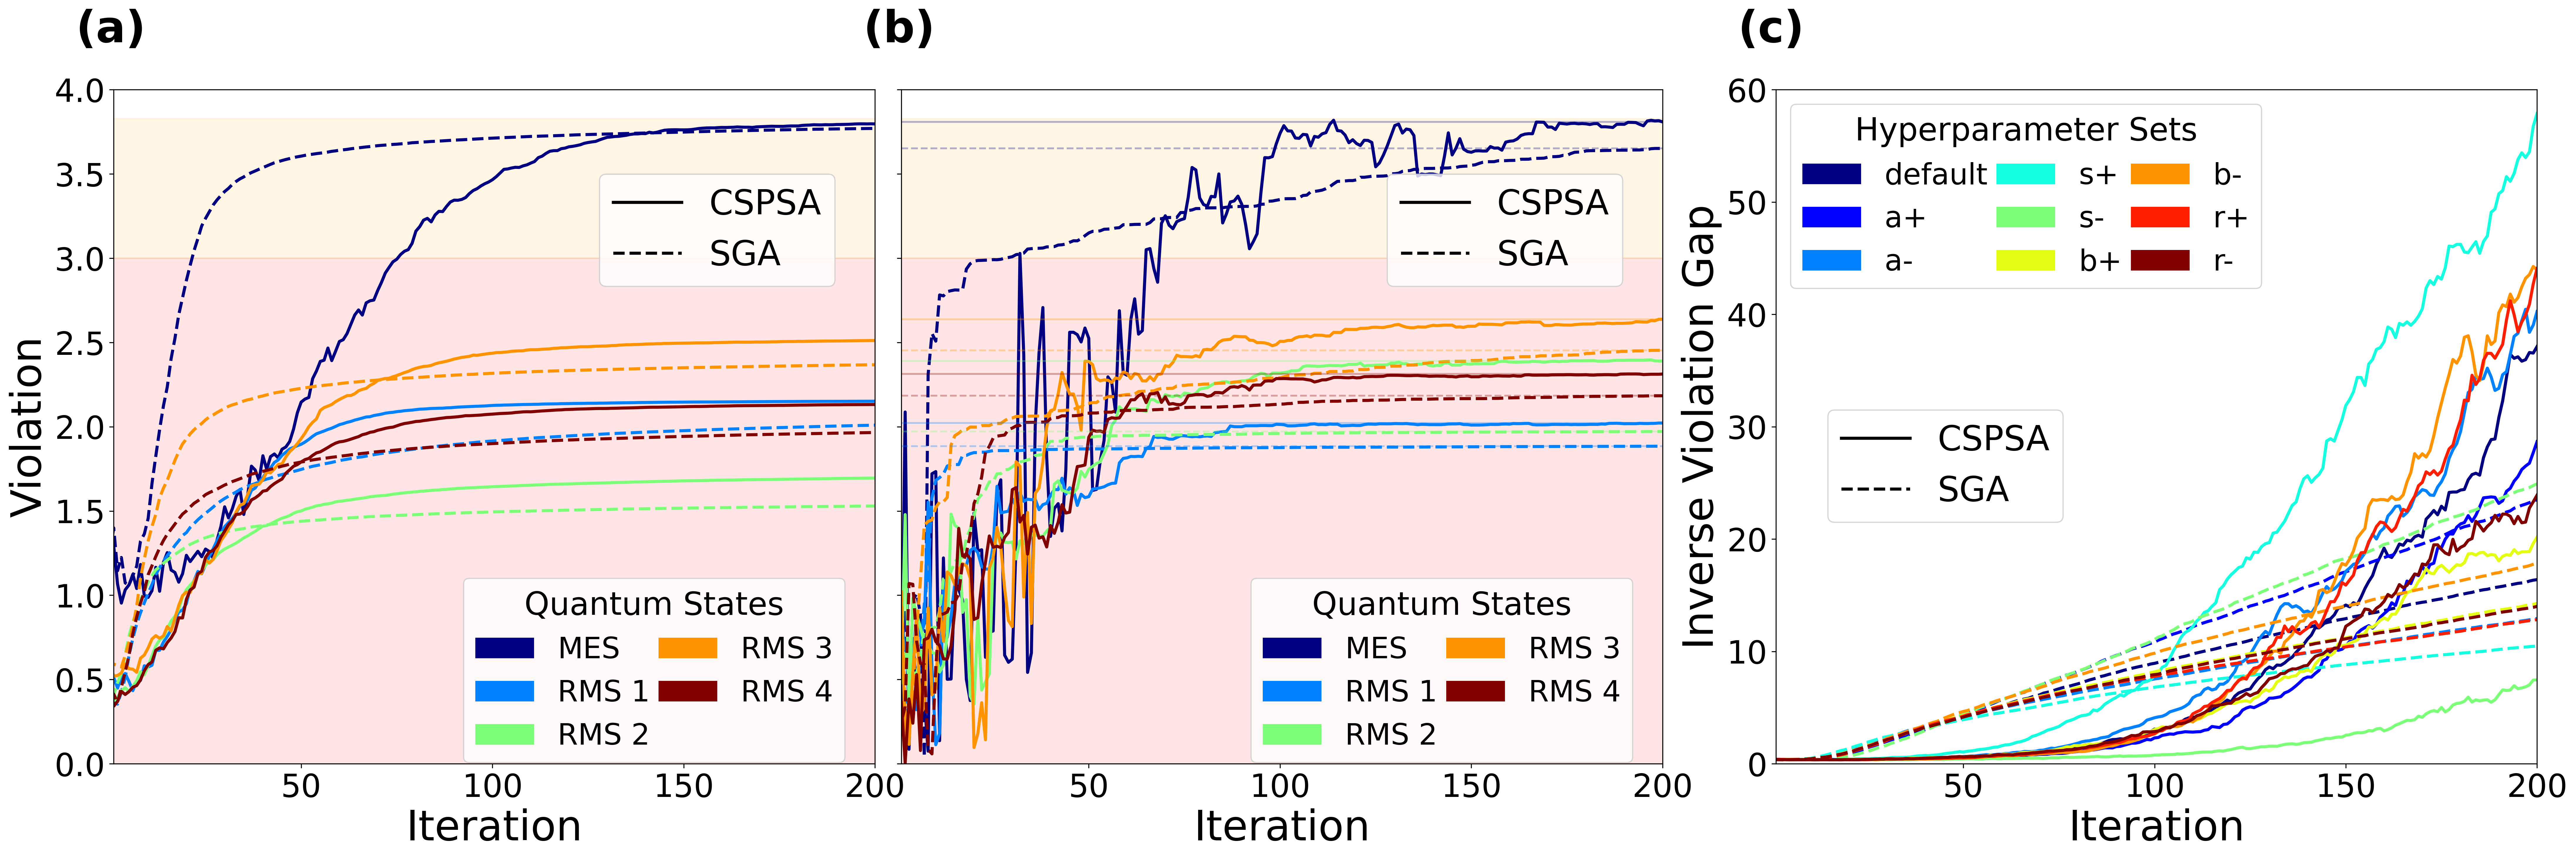

In [26]:
# =============================================================================
# --- 6. Plotting (Plotting Figure 2) ---
# =============================================================================
print("Generating Figure 2...")
# Create three-panel layout
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 9), sharey=False, dpi=300)
plt.style.use('default')

algo_lines = {'CSPSA': '-', 'SGA': '--'}

# --- Panel (a): Efficiency comparison (using results_1a) ---
colors_1a = plt.cm.jet(np.linspace(0, 1, len(STATES_1a)))
state_colors_1a = {name: colors_1a[i] for i, name in enumerate(STATES_1a.keys())}

# Define violation bounds
local_bound = 3.0
quantum_bound = 1 + 2 * np.sqrt(2)  # ≈ 3.828

# Find the overall maximum violation for setting y-axis limits consistently
all_violations_1a = np.concatenate([r['mean_history'] for r in results_1a])
overall_max_violation_1a = all_violations_1a.max()

# Add background color regions for violation indication
ax1.axhspan(0, local_bound, alpha=0.1, color='red', label='Local bound region')
ax1.axhspan(local_bound, quantum_bound, alpha=0.1, color='orange', label='Quantum violation region')
ax1.axhspan(quantum_bound, 4.0, alpha=0.1, color='white', label='Beyond quantum bound')

for r in results_1a:
   ax1.plot(r['mean_history'],
             color=state_colors_1a[r['state_name']],
             linestyle=algo_lines[r['algo_name']],
             linewidth=2.5)

ax1.text(-0.05, 1.12, '(a)', transform=ax1.transAxes, fontsize=36, fontweight='bold', va='top')
ax1.set_ylim(bottom=0, top=4.0)
ax1.set_xlabel("Iteration", fontsize=34)
ax1.set_ylabel("Violation", fontsize=34)
ax1.grid(False)
ax1.tick_params(axis='both', which='major', labelsize=26)
ax1.set_xlim(1, 200)

# Legend (a)
leg_states_1a = [Patch(facecolor=state_colors_1a[name], label=name) for name in STATES_1a.keys()]
leg_algos = [Line2D([0], [0], color='black', lw=2.5, linestyle=ls, label=name) for name, ls in algo_lines.items()]
legend1 = ax1.legend(handles=leg_states_1a, loc='lower right', bbox_to_anchor=(0.98, -0.02), title='Quantum States', ncol=2, columnspacing=0.3, fontsize=24, title_fontsize=26)
ax1.add_artist(legend1)
ax1.legend(handles=leg_algos, loc='upper right', bbox_to_anchor=(0.97, 0.90), fontsize=28)

# --- Panel (b): Efficiency comparison (using results_single, with horizontal lines) ---
colors_single = plt.cm.jet(np.linspace(0, 1, len(STATES_single)))
state_colors_single = {name: colors_single[i] for i, name in enumerate(STATES_single.keys())}

# Add background color regions for violation indication
ax2.axhspan(0, local_bound, alpha=0.1, color='red', label='Local bound region')
ax2.axhspan(local_bound, quantum_bound, alpha=0.1, color='orange', label='Quantum violation region')
ax2.axhspan(quantum_bound, 4.0, alpha=0.1, color='white', label='Beyond quantum bound')

# Store final violation values for drawing horizontal lines
final_violations = {}

for r in results_single:
   ax2.plot(r['mean_history'],
             color=state_colors_single[r['state_name']],
             linestyle=algo_lines[r['algo_name']],
             linewidth=2.5)
   
   # Get final violation value (300th iteration)
   final_violation = r['mean_history'][-1]  # Last value
   key = f"{r['state_name']}_{r['algo_name']}"
   final_violations[key] = final_violation

# Add horizontal lines to show final violation values
for r in results_single:
    key = f"{r['state_name']}_{r['algo_name']}"
    final_violation = final_violations[key]
    ax2.axhline(y=final_violation, 
                color=state_colors_single[r['state_name']], 
                linestyle=algo_lines[r['algo_name']], 
                alpha=0.3, 
                linewidth=1.5)

ax2.text(-0.05, 1.12, '(b)', transform=ax2.transAxes, fontsize=36, fontweight='bold', va='top')
ax2.set_xlabel("Iteration", fontsize=34)
# Remove y-axis label and tick labels for panel b, but keep ticks
ax2.set_yticklabels([])
ax2.grid(False)
ax2.tick_params(axis='y', which='major', labelsize=0)  # Hide y-axis tick labels
ax2.tick_params(axis='x', which='major', labelsize=26)  # Keep x-axis tick labels
ax2.set_xlim(1, 200)
ax2.set_ylim(bottom=0, top=4.0)

# Legend (b)
leg_states_single = [Patch(facecolor=state_colors_single[name], label=name) for name in STATES_single.keys()]
legend2 = ax2.legend(handles=leg_states_single, loc='lower right', bbox_to_anchor=(0.98, -0.02), title='Quantum States', ncol=2, columnspacing=0.3, fontsize=24, title_fontsize=26)
ax2.add_artist(legend2)
ax2.legend(handles=leg_algos, loc='upper right', bbox_to_anchor=(0.97, 0.900), fontsize=28)

# --- Panel (c): Hyperparameter effects (subfig3: Changed) ---
colors_1b = plt.cm.jet(np.linspace(0, 1, len(HPARAMS_1b)))
hparam_colors = {name: colors_1b[i] for i, name in enumerate(HPARAMS_1b.keys())}

# Define maximal_violation for the transformation
maximal_violation = 1 + 2 * np.sqrt(2)

for r in results_1b:
   # Calculate the new y-axis values for ax3 only
   violation = r['mean_history']
   y_values = 1 / (maximal_violation - violation)
   ax3.plot(y_values,
             color=hparam_colors[r['hparam_set']],
             linestyle=algo_lines[r['algo_name']],
             linewidth=2.5)

ax3.text(-0.05, 1.12, '(c)', transform=ax3.transAxes, fontsize=36, fontweight='bold', va='top')
ax3.set_xlabel("Iteration", fontsize=34)
ax3.set_ylabel("Inverse Violation Gap", fontsize=34)
ax3.grid(False)
ax3.tick_params(axis='both', which='major', labelsize=26)
ax3.set_xlim(1, 200)
ax3.set_ylim(0, 60)

# Legend (c)
leg_hparams = [Patch(facecolor=hparam_colors[name], label=name) for name in HPARAMS_1b.keys()]
legend3 = ax3.legend(handles=leg_hparams, loc='upper left', ncol=3, columnspacing=0.3, title='Hyperparameter Sets', fontsize=24, title_fontsize=26)
ax3.add_artist(legend3)
ax3.legend(handles=leg_algos, loc='upper right', bbox_to_anchor=(0.4, 0.55), fontsize=28)

# --- Global settings ---
# Control spacing between panels individually
# Panel a/b spacing: very tight (0.01)
# Panel b/c spacing: normal (0.1)
fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.1, wspace=0.01)

# Manually adjust panel positions for different spacing
# Get current positions
pos1 = ax1.get_position()
pos2 = ax2.get_position() 
pos3 = ax3.get_position()

# Adjust panel b position to be closer to panel a
# Move panel b left to reduce gap with panel a
ax2.set_position([pos1.x1 + 0.01, pos2.y0, pos2.width, pos2.height])

# Adjust panel c position to maintain desired gap with panel b
# Move panel c to maintain normal spacing from panel b
ax3.set_position([pos2.x1 + 0.05, pos3.y0, pos3.width, pos3.height])

plt.savefig("figure2.pdf", format='pdf', bbox_inches='tight')
plt.show()